# 렐루(ReLU)

- 신경망에서 활성화되는 신호를 결정하는 단순하지만 강력한 함수 
- `양수` 입력에 대해서는 `입력값 그대로`
- `음수` 입력에 대해서는 `0을 반환`
- `은닉층`에서 사용이 권장
- 신경망이 비선형 문제를 해결하는데 필수적인 비선형성을 제공하면서도 계산상의 부담을 최소화 
- `ReLU`는 그라디언트 소실 문제를 완화 하는데 도움을 줄 수 있으며, 신경망이 더 깊어질때 유용 

## 특징

- 빠른 연산 능력을 가지며, 신경망의 기울기가 극단적으로 작아지거나 사라지는 그라디언트 소실 문제를 완화 시켜줌. 

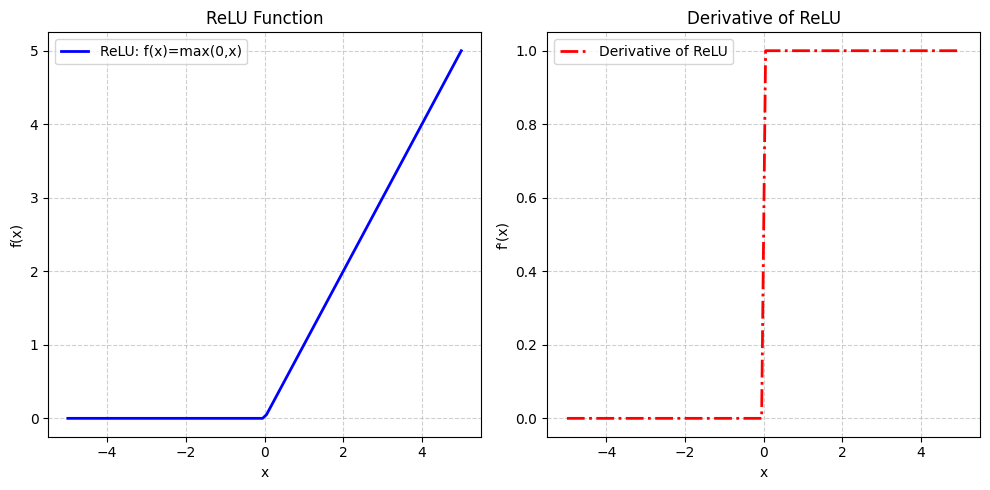

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. ReLU 함수 정의
def relu(x):
    return np.maximum(0, x)

# 2. ReLU 미분 함수 정의
def relu_derivative(x):
    # x가 0보다 크면 1, 아니면 0을 반환
    return np.where(x > 0, 1, 0)

# x축 데이터 생성 (-5 부터 5까지 일정 간격으로 100개의 점 생성)
x = np.linspace(-5, 5, 100)

# y축 데이터 계산
y_relu = relu(x)
y_derivative = relu_derivative(x)

# 그래프 그리기 설정 (가로 10, 세로 5 크기)
plt.figure(figsize=(10, 5))

# --- 첫 번째 그래프: ReLU ---
plt.subplot(1, 2, 1)
plt.plot(x, y_relu, label="ReLU: f(x)=max(0,x)", color="blue", linewidth=2)
plt.title("ReLU Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# --- 두 번째 그래프: ReLU 미분 ---
plt.subplot(1, 2, 2)
plt.plot(x, y_derivative, label="Derivative of ReLU", color="red", linewidth=2, linestyle="-.")
plt.title("Derivative of ReLU")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 그래프 간격 조절 및 출력
plt.tight_layout()
plt.show()

## 1. ReLU 함수의 수학적 정의

ReLU는 "0보다 작으면 0을 출력하고, 0보다 크면 입력값을 그대로 출력한다"는 아주 직관적인 원리를 가집니다.

**[함수식]**


$$f(x) = \max(0, x)$$

이를 앞서 다루었던 조건부 수식으로 풀어서 쓰면 다음과 같습니다.


$$f(x) = \begin{cases} 0 & (x \le 0) \\ x & (x > 0) \end{cases}$$

**[미분식]**
기울기(미분값) 계산 역시 굉장히 단순합니다. $x$가 0 이하일 때는 뻗어나가는 기울기가 아예 없으니 0이고, 0보다 클 때는 $y=x$ 그래프와 같으므로 기울기가 항상 1입니다.


$$f'(x) = \begin{cases} 0 & (x \le 0) \\ 1 & (x > 0) \end{cases}$$

> **💡 수학적 여담:** 엄밀히 말해 $x=0$인 뾰족한 점에서는 수학적으로 미분이 불가능합니다. 하지만 실제 PyTorch나 TensorFlow 같은 딥러닝 프레임워크에서는 실용적인 목적을 위해 이 지점의 미분값을 그냥 0(또는 드물게 1)으로 강제 할당하여 계산합니다.

In [2]:
import torch

x = torch.tensor([-1.0, 2.0, -3.0, 4.0, -5.0])
relu_output = torch.relu(x)

print(relu_output)

tensor([0., 2., 0., 4., 0.])


In [4]:
import torch.nn as nn
# 선형 층 정의
linear_layer = nn.Linear(in_features=5, out_features=1)

input_tensor = torch.randn(1, 5)

linear_output = linear_layer(input_tensor)
print("\n선형(Linear) 레이어 출력:\n", linear_output)

relu_output = torch.relu(linear_output)
print("\n렐루(Relu) 레이어 출력:\n", relu_output)


선형(Linear) 레이어 출력:
 tensor([[-0.8770]], grad_fn=<AddmmBackward0>)

렐루(Relu) 레이어 출력:
 tensor([[0.]], grad_fn=<ReluBackward0>)
